# Pt 3 - Visual encoding demos

## Common libraries and basic plotting

In [1]:
import matplotlib.pyplot as plt  # basic basics
import seaborn as sns  # prettier; more plot types; does stats
import pandas as pd  # plotting is just one thing it can do
import plotly.express as px  # interactive
import numpy as np  # for simulating data, not for visualization


np.random.seed(18)

## Let's make a bar chart with this data:

In [2]:
x = ["a", "b", "c"]
y = [1, 3, 2]

### Matplotlib
basic basics

<BarContainer object of 3 artists>

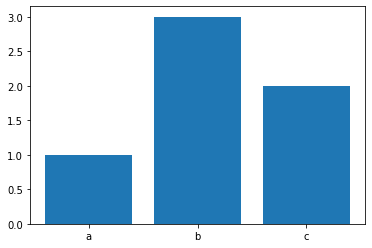

In [3]:
plt.bar(x=x, height=y)

### Seaborn
- prettier
- more plot types
- does stats
- works well with pandas dataframes

<AxesSubplot:>

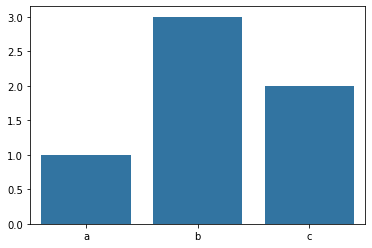

In [4]:
sns.barplot(x=x, y=y)

### Pandas
- great for dealing with tabular data
- plotting is just one thing it can do

In [4]:
df = pd.DataFrame(data={"x": x, "y": y})
df

,x,y
0,a,1
1,b,3
2,c,2


<AxesSubplot:xlabel='x'>

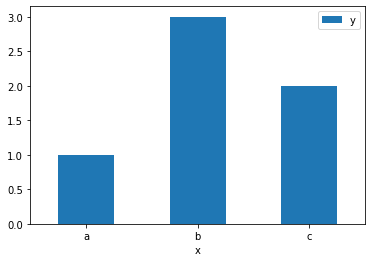

In [6]:
df.plot.bar(x="x", y="y", rot=0)

### Plotly
- interactive
- can be made into a dashboard with plotly dash

In [7]:
fig_px = px.bar(x=x, y=y)
fig_px.show()

## Now let's put them in one plot using subplots
Notice some similarities/differences in how you input the data

**It's okay to Google this!** 

IndexError: index 3 is out of bounds for axis 0 with size 3

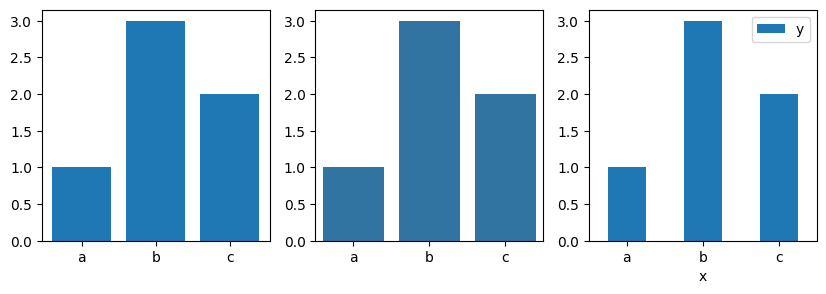

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3))
axs[0].bar(x=x, height=y)
sns.barplot(x=x, y=y, ax=axs[1])
df.plot.bar(x="x", y="y", rot=0, ax=axs[2])
px.bar(x=x, y=y, ax=axs[3])

### plotly is special! 

Now we've got the basics down, let's make

# More complicated plots

while learning data vis do's and don't's

https://github.com/cxli233/FriendsDontLetFriends/tree/main

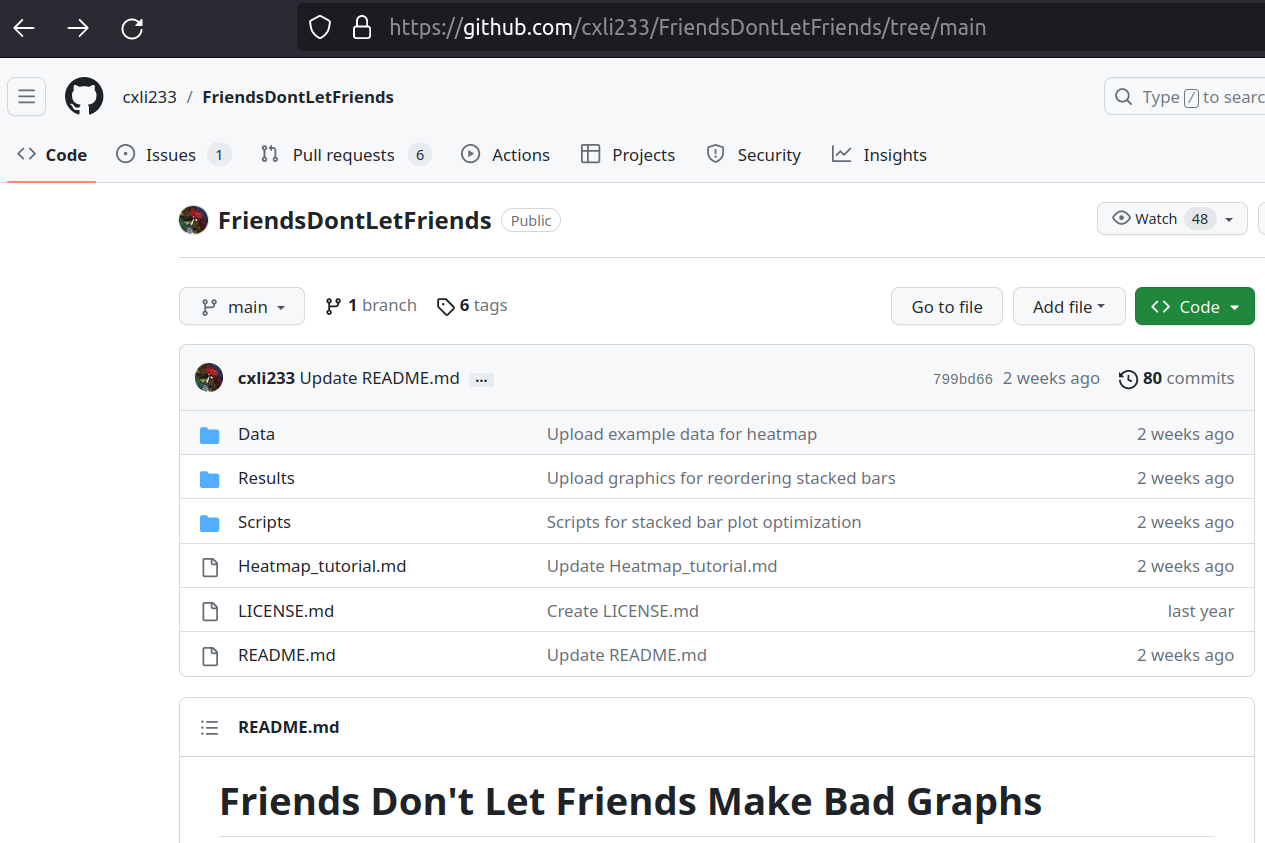

# Friends Don't Let Friends Make Bar Plots for Means Separation
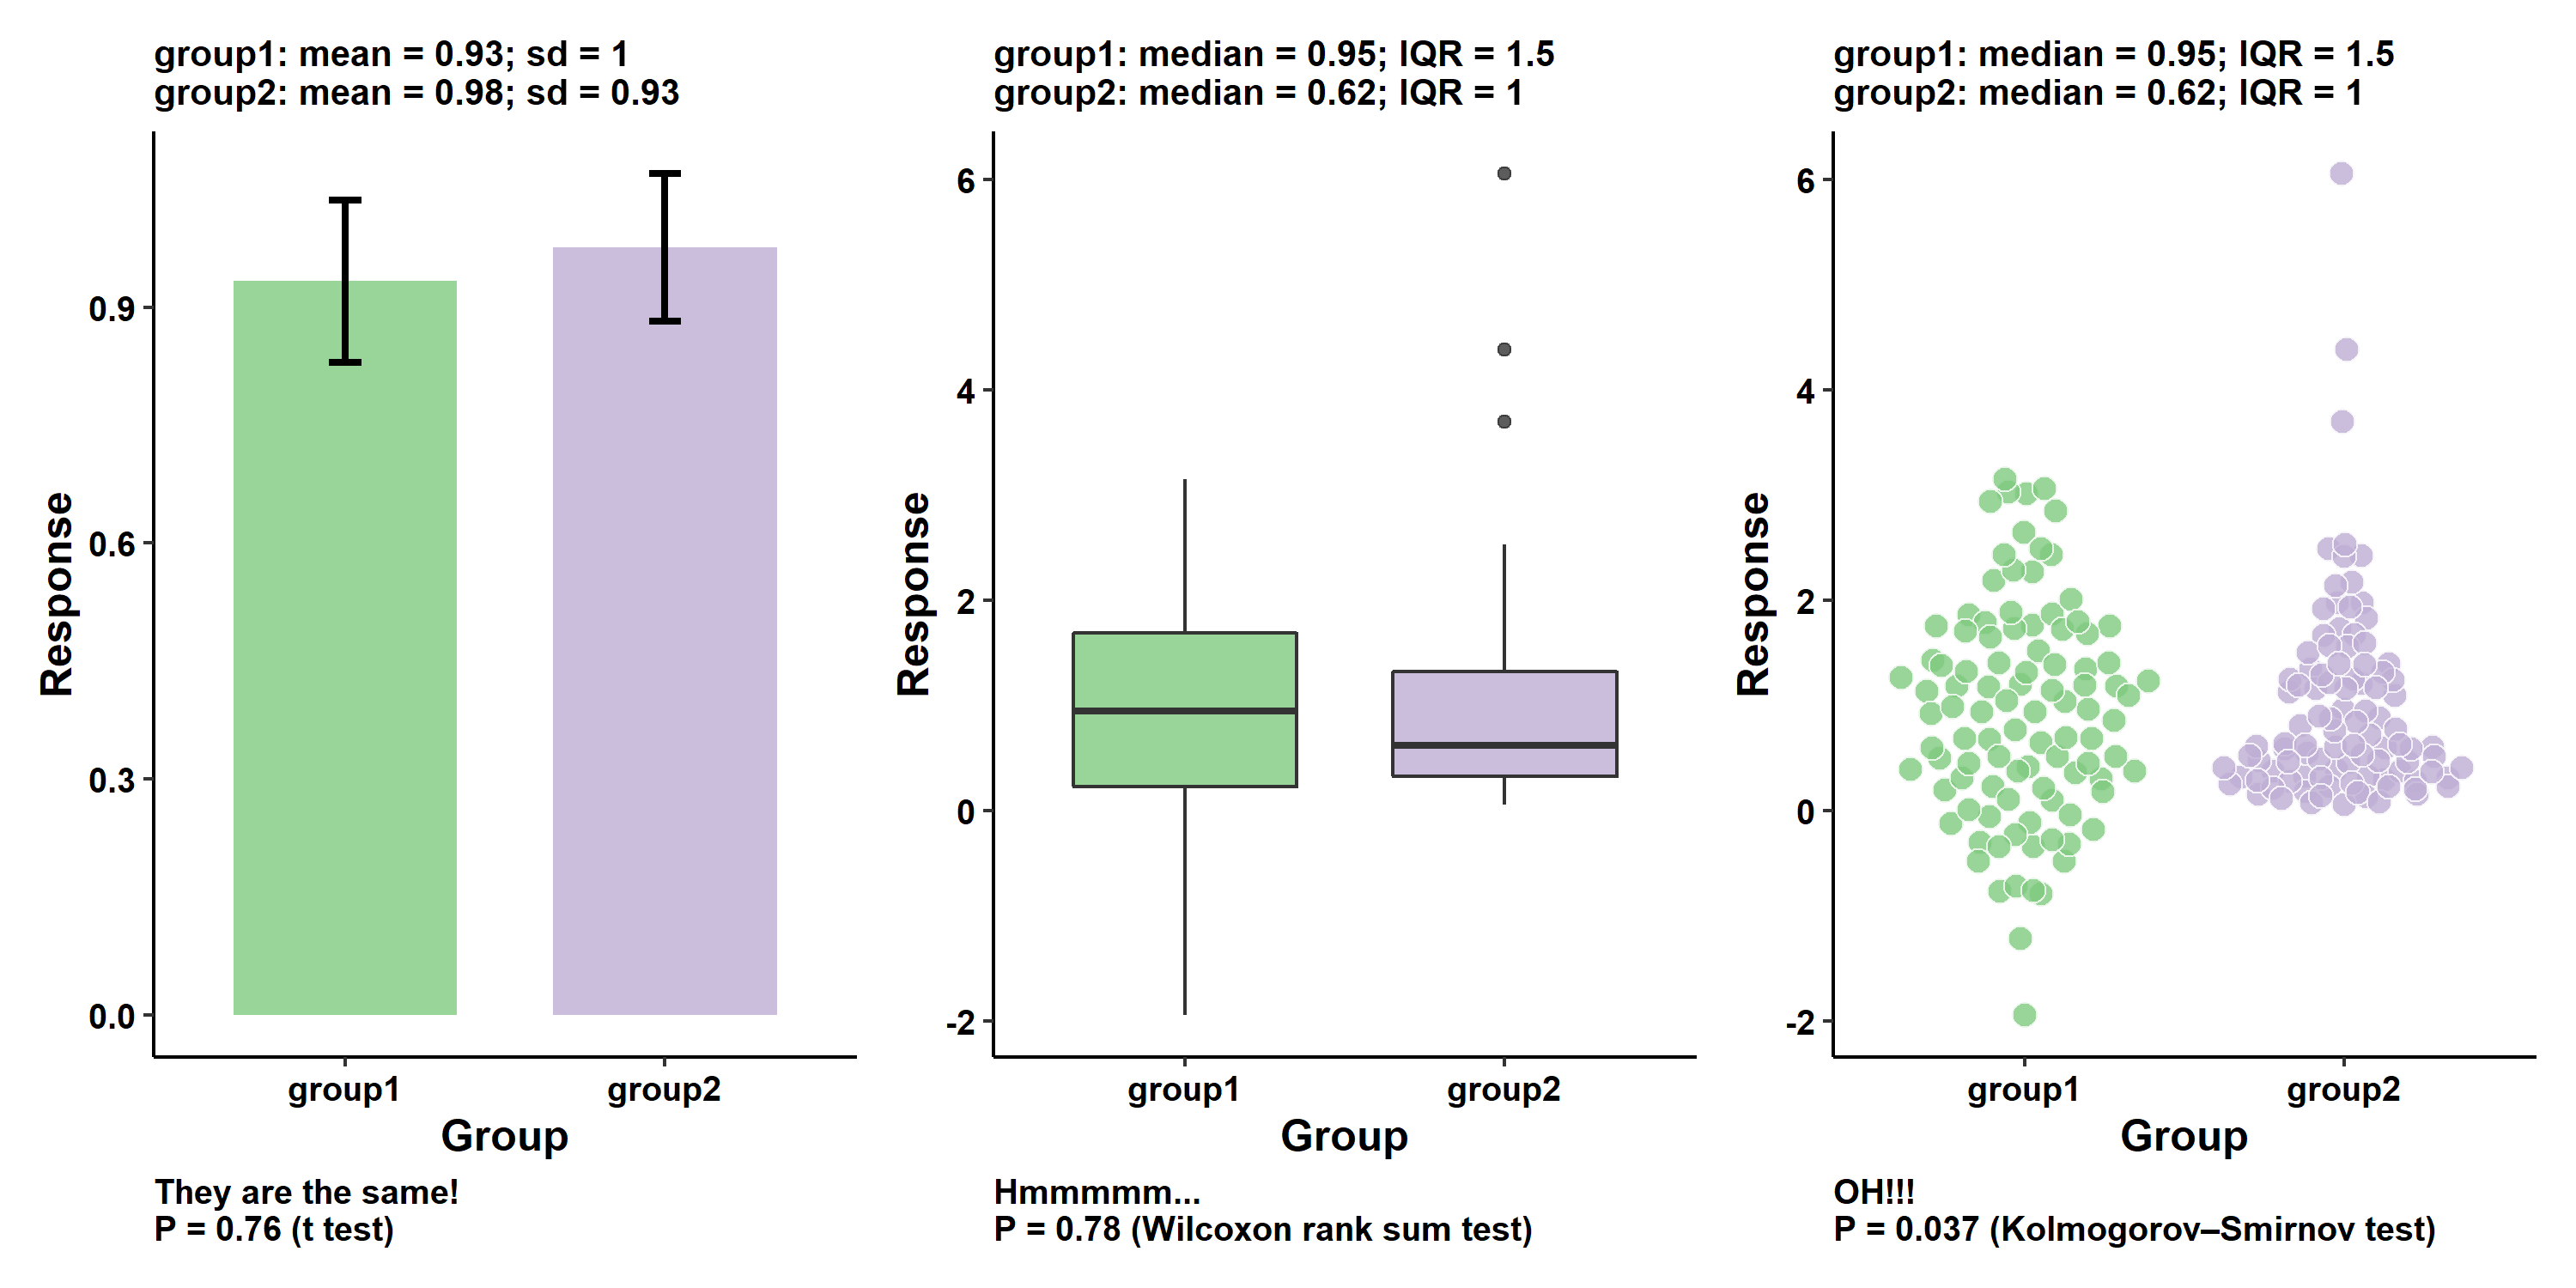
https://github.com/cxli233/FriendsDontLetFriends/raw/main/Results/dont_bar_plot.png

## first let's simulate the data

In [9]:
n = 100
group1 = np.random.normal(loc=1, scale=1, size=n)
group2 = np.random.lognormal(size=n, mean=np.log(1 / np.sqrt(2)), sigma=np.sqrt(np.log(2)))
df_wide = pd.DataFrame(data={"group1": group1, "group2": group2})
df_wide

,group1,group2
0,1.079428,0.259301
1,3.190202,1.316818
2,0.865108,1.855422
3,1.160518,1.275979
4,1.442698,1.925820
...,...,...
95,0.813967,0.869613
96,2.192779,0.858532
97,3.362198,1.930707
98,-0.561812,0.275471


## let's put it in long form


In [10]:
data = {
    "val": np.concatenate([group1, group2]),
    "label": np.concatenate([["group1"] * n, ["group2"] * n]),
}
df_long = pd.DataFrame(data)
df_long

,val,label
0,1.079428,group1
1,3.190202,group1
2,0.865108,group1
3,1.160518,group1
4,1.442698,group1
...,...,...
195,0.869613,group2
196,0.858532,group2
197,1.930707,group2
198,0.275471,group2


## it's super easy to make these different plots in seaborn

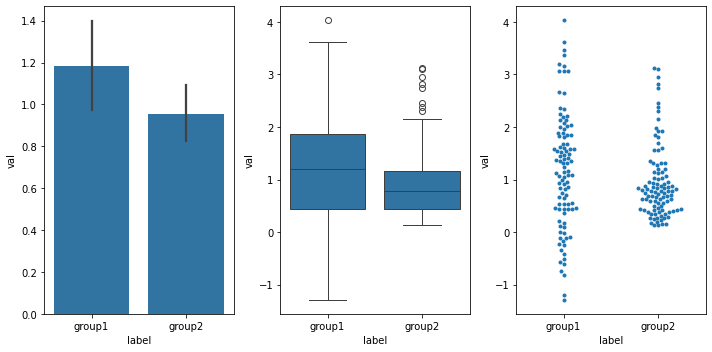

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5))
sns.barplot(data=df_long, x="label", y="val", ax=axs[0])
sns.boxplot(data=df_long, x="label", y="val", ax=axs[1])
sns.swarmplot(data=df_long, x="label", y="val", ax=axs[2], size=4)
plt.tight_layout()

## Things to ponder
- the bar plot starts at 0 on the y axis, but there are negative numbers
- how could we redundantly encode information?
- what if we still want to see the mean and statistical spread?

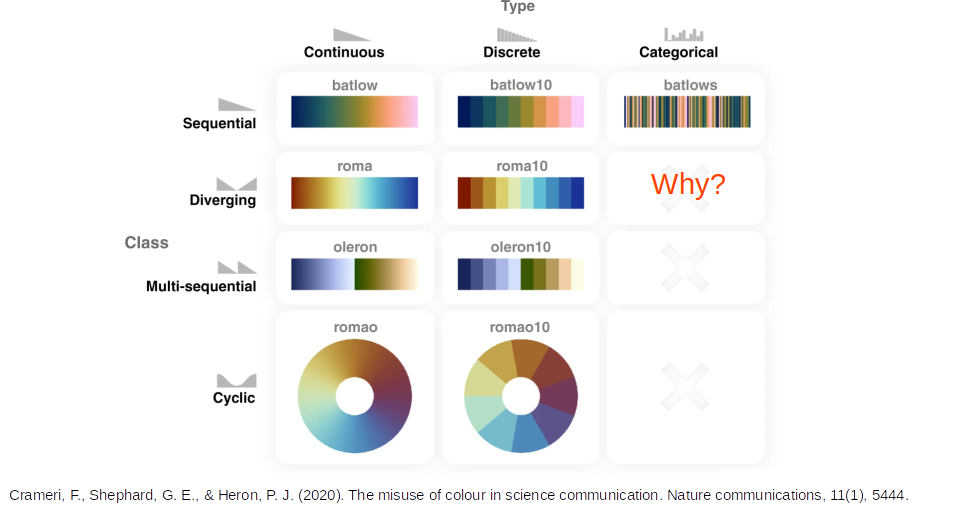

/var/folders/bx/z6474k1x4hl7tmn54rd53x3m0000gn/T/ipykernel_74635/3300177296.py:21: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



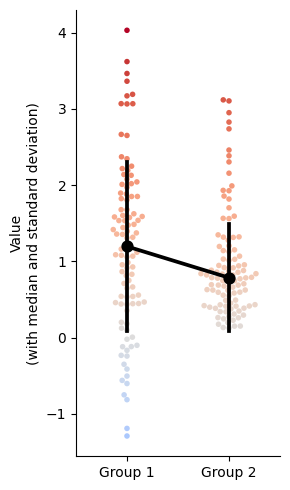

In [11]:
from matplotlib import colors


fig, ax = plt.subplots(1, 1, figsize=(3, 5))
divnorm = colors.TwoSlopeNorm(vmin=-1 * df_long.val.max(), vcenter=0.0, vmax=np.max(df_long["val"]))
sns.swarmplot(
    data=df_long,
    x="label",
    y="val",
    hue_norm=divnorm,
    ax=ax,
    size=4,
    hue="val",
    palette="coolwarm",
    zorder=0,
)
sns.pointplot(
    data=df_long, x="label", y="val", estimator=np.median, errorbar="sd", color="k", zorder=1
)
ax.get_legend().remove()
ax.set_xticklabels(["Group 1", "Group 2"])
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylabel("Value\n(with median and standard deviation)")
ax.set_xlabel("")
plt.tight_layout()

# Friends Don't Let Friends Make Pie Chart
![image.png](https://raw.githubusercontent.com/cxli233/FriendsDontLetFriends/main/Results/dont_pie_chart.svg)


https://github.com/cxli233/FriendsDontLetFriends/raw/main/Results/dont_pie_chart.svg

## Is there an even better way?

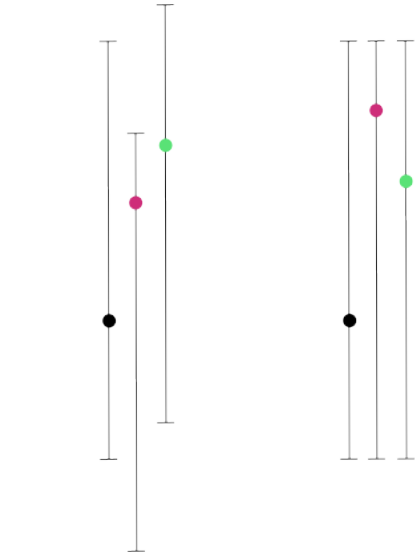

## First, let's make the data

In [12]:
types = ["Type I", "Type II", "Type III", "Type IV"]
percents1 = [15, 35, 30, 20]
percents2 = [10, 25, 35, 30]

df1 = pd.DataFrame({"Types": types, "Percents": percents1}).set_index("Types")
df2 = pd.DataFrame({"Types": types, "Percents": percents2}).set_index("Types")
df2

,Percents
Types,
Type I,10
Type II,25
Type III,35
Type IV,30


## Another way to make subplots, 
which allows you to make different-sized subplots

ValueError: num must be an integer with 1 <= num <= 4, not 17

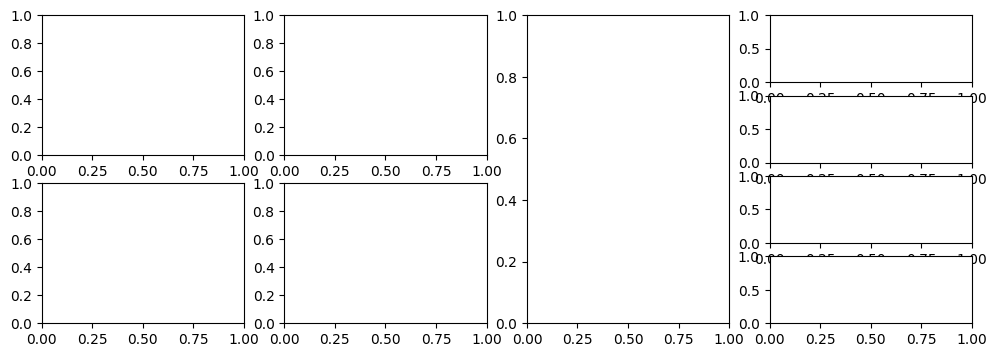

In [ ]:
fig = plt.figure(figsize=(12, 4))
ax_topleft = fig.add_subplot(2, 4, 1)
ax_topmid = fig.add_subplot(2, 4, 2)
ax_lowleft = fig.add_subplot(2, 4, 5)
ax_lowmid = fig.add_subplot(2, 4, 6)
ax_2ndright = fig.add_subplot(1, 4, 3)
ax_right1 = fig.add_subplot(4, 4, 4)
ax_right2 = fig.add_subplot(4, 4, 8)
ax_right3 = fig.add_subplot(4, 4, 12)
ax_right4 = fig.add_subplot(4, 4, 16)

/var/folders/bx/z6474k1x4hl7tmn54rd53x3m0000gn/T/ipykernel_74635/1127888739.py:50: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



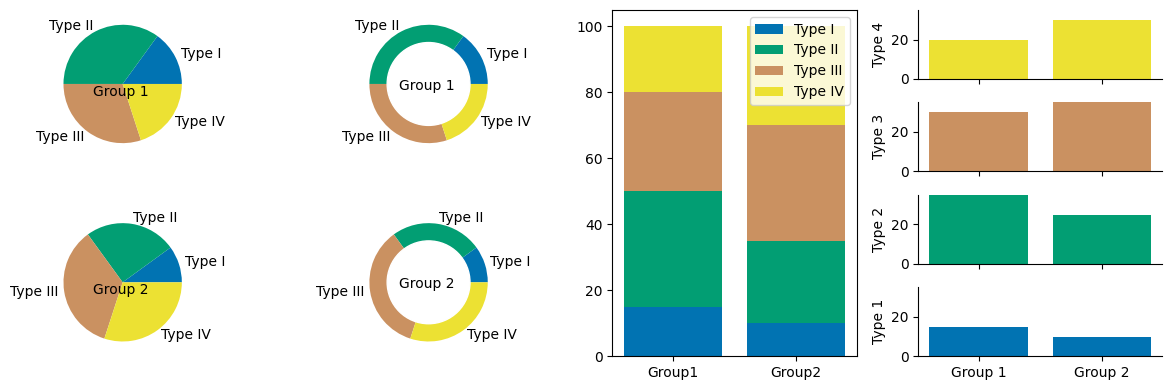

In [13]:
fig = plt.figure(figsize=(12, 4))
ax_topleft = fig.add_subplot(2, 4, 1)
ax_topmid = fig.add_subplot(2, 4, 2)
ax_lowleft = fig.add_subplot(2, 4, 5)
ax_lowmid = fig.add_subplot(2, 4, 6)
ax_2ndright = fig.add_subplot(1, 4, 3)
ax_right1 = fig.add_subplot(4, 4, 4)
ax_right2 = fig.add_subplot(4, 4, 8)
ax_right3 = fig.add_subplot(4, 4, 12)
ax_right4 = fig.add_subplot(4, 4, 16)

palette = list(sns.color_palette("colorblind"))
colors = [palette[i] for i in [0, 2, 5, 8]]

# pie charts
df1.plot.pie(y="Percents", legend=False, ax=ax_topleft, colors=colors, label="")
df2.plot.pie(y="Percents", legend=False, ax=ax_lowleft, colors=colors, label="")
ax_topleft.text(-0.5, -0.2, s="Group 1")
ax_lowleft.text(-0.5, -0.2, s="Group 2")


#  hacking a donut chart
df1.plot.pie(y="Percents", legend=False, ax=ax_topmid, colors=colors, label="")
df2.plot.pie(y="Percents", legend=False, ax=ax_lowmid, colors=colors, label="")
ax_topmid.add_artist(plt.Circle((0, 0), 0.7, color="white"))
ax_lowmid.add_artist(plt.Circle((0, 0), 0.7, color="white"))
ax_topmid.text(-0.5, -0.1, s="Group 1")
ax_lowmid.text(-0.5, -0.1, s="Group 2")

# stacked bar chart
df = df1.copy()
df = df.rename(columns={"Percents": "Group1"})
df["Group2"] = df2["Percents"]
last = np.array([0, 0])
for (type, row), color in zip(df.iterrows(), colors):
    ax_2ndright.bar(x=row.index, height=row.values, bottom=last, label=type, color=color)
    last = row + last
ax_2ndright.legend()

# stack of bar charts
right_axs = [ax_right1, ax_right2, ax_right3, ax_right4][::-1]
i_chart = 0
for (type, row), ax, color in zip(df.iterrows(), right_axs, colors):
    i_chart += 1
    ax.bar(x=row.index, height=row.values, color=color)
    ax.set_ylabel(f"Type {i_chart}", rotation=90)
    ax.set_ylim((0, df.max().max()))
    ax.spines[["right", "top"]].set_visible(False)
    ax.set_xticklabels([])
ax_right4.set_xticklabels(["Group 1", "Group 2"])

plt.tight_layout()